# **Experiment 1:** 
To develop a program to simulate and analyze the characteristics of common communication noises.

## **Objective:**
To write a program that analyzes the effect of communication noise, specifically focusing on **AWGN**, **Impulse noise**, **Thermal noise**, and **Random noise**, and understand how they affect the quality of transmitted signals.

## **Theory:**
In communication systems, noise refers to any unwanted signal that interferes with the transmission of data. Common types of noise include:

- **Additive White Gaussian Noise (AWGN):** A widely used noise model in communication systems.  
  - *Additive* means the noise is directly added to the signal.  
  - *White* means it has constant power across all frequencies.  
  - *Gaussian* means the noise amplitude follows a normal distribution.  
  AWGN is commonly used to represent real-world channel noise.

- **Impulse Noise:** Sudden spikes or short-duration disturbances that significantly degrade signal quality, often caused by switching or external interference.

- **Thermal Noise:** Noise generated due to random motion of electrons in conductors. It is always present in electronic systems and is often modeled as Gaussian.

- **Random Noise:** Noise with unpredictable variations in amplitude and distribution.

Noise degrades signal quality. The **Signal-to-Noise Ratio (SNR)** is used to measure signal quality and is defined as:

$$
\text{SNR (dB)} = 10 \log_{10} \left( \frac{P_{signal}}{P_{noise}} \right)
$$

Higher SNR indicates better signal quality.

## **Algorithm:**
1. **Generate a clean signal**: A sine wave is used as the original signal.
2. **Add AWGN noise**: Generate noise based on a desired SNR and add it to the signal.
3. **Add Impulse noise**: Introduce random spikes at random positions.
4. **Add Thermal noise**: Add low-variance Gaussian noise.
5. **Add Random noise**: Add uniformly distributed random noise.
6. **Analyze signals**: Plot clean and noisy signals.
7. **Compute SNR**: Calculate SNR for each noise type.

## **Code:**

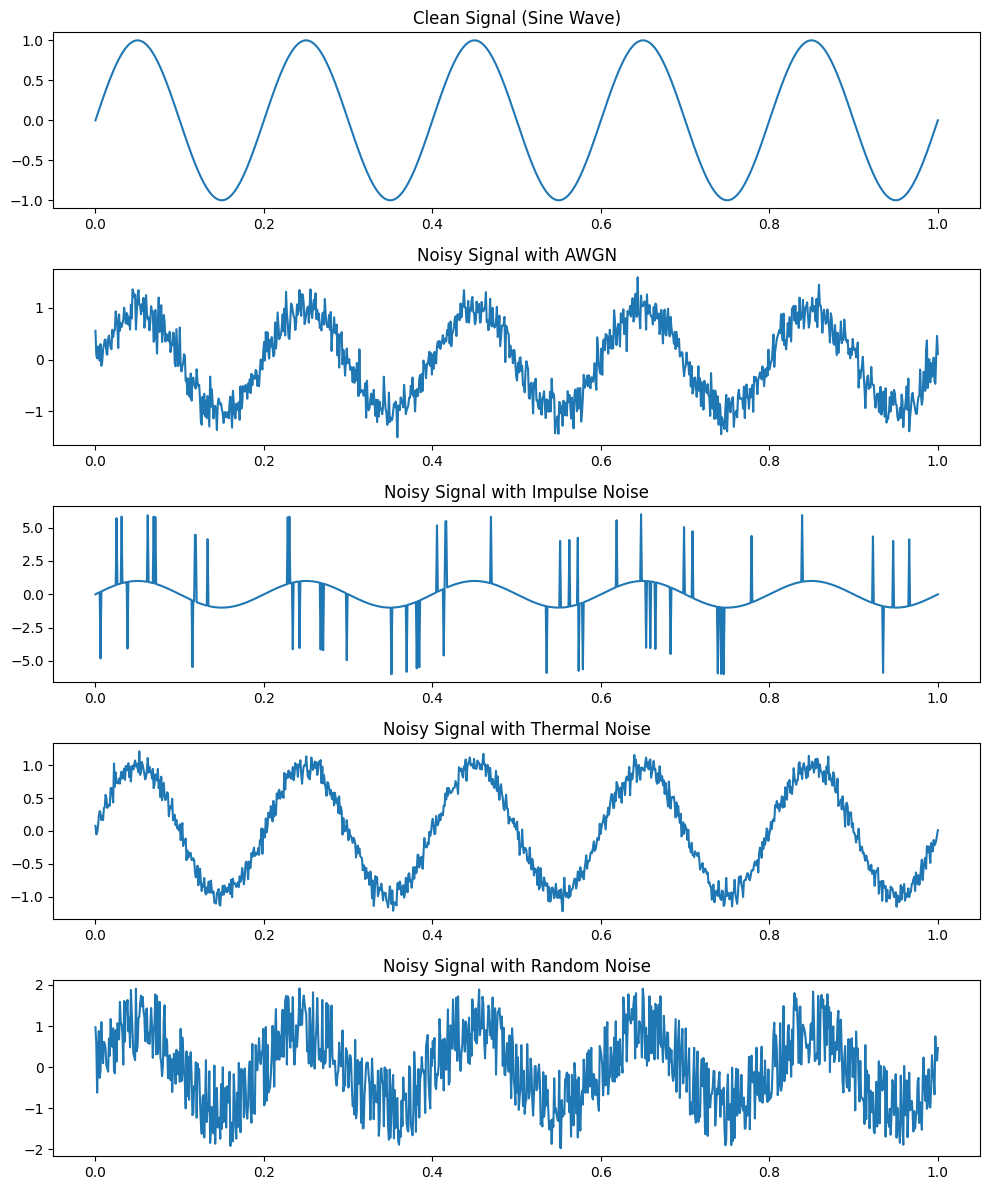

SNR AWGN: 10.19 dB
SNR Impulse: -3.98 dB
SNR Thermal: 16.81 dB
SNR Random: 1.76 dB


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a clean signal (sine wave)
fs = 1000
t = np.linspace(0, 1, fs)
freq = 5
clean_signal = np.sin(2 * np.pi * freq * t)

# 1. AWGN Noise (Modified)
snr_db = 10  # Desired SNR in dB
signal_power = np.mean(clean_signal**2)
snr_linear = 10**(snr_db / 10)
noise_power = signal_power / snr_linear

awgn_noise = np.random.normal(0, np.sqrt(noise_power), fs)
noisy_signal_awgn = clean_signal + awgn_noise

# 2. Impulse Noise
impulse_noise = np.zeros(fs)
impulse_positions = np.random.randint(0, fs, size=50)
impulse_noise[impulse_positions] = np.random.choice([-5, 5], size=50)
noisy_signal_impulse = clean_signal + impulse_noise

# 3. Thermal Noise
thermal_noise = np.random.normal(0, 0.1, fs)
noisy_signal_thermal = clean_signal + thermal_noise

# 4. Random Noise
random_noise = np.random.uniform(-1, 1, fs)
noisy_signal_random = clean_signal + random_noise

# Plot
plt.figure(figsize=(10, 12))

plt.subplot(5, 1, 1)
plt.plot(t, clean_signal)
plt.title("Clean Signal (Sine Wave)")

plt.subplot(5, 1, 2)
plt.plot(t, noisy_signal_awgn)
plt.title("Noisy Signal with AWGN")

plt.subplot(5, 1, 3)
plt.plot(t, noisy_signal_impulse)
plt.title("Noisy Signal with Impulse Noise")

plt.subplot(5, 1, 4)
plt.plot(t, noisy_signal_thermal)
plt.title("Noisy Signal with Thermal Noise")

plt.subplot(5, 1, 5)
plt.plot(t, noisy_signal_random)
plt.title("Noisy Signal with Random Noise")

plt.tight_layout()
plt.show()

# SNR
def snr(signal, noise):
    return 10 * np.log10(np.var(signal) / np.var(noise))

print(f"SNR AWGN: {snr(clean_signal, awgn_noise):.2f} dB")
print(f"SNR Impulse: {snr(clean_signal, impulse_noise):.2f} dB")
print(f"SNR Thermal: {snr(clean_signal, thermal_noise):.2f} dB")
print(f"SNR Random: {snr(clean_signal, random_noise):.2f} dB")